# M1 — PPO RL Agent for Autonomous 5G QoS Optimization
**Module:** DSO3.1 · Reinforcement Learning Agent
**Author:** Member 1 — Data Science
**Env input:** `QoSNetworkEnv` (Digital Twin, M4 handoff)
**Dataset:** NS-3 LENA 5G · 18 580 rows · 5 UEs

---
### Architecture
```
Real Network ──► Digital Twin (QoSNetworkEnv) ──► PPO Agent
                      ↑ safe sandbox                    │
                      └────── validated actions ◄────────┘
```

### What this notebook does
| Section | Content |
|---|---|
| 1 | Environment validation & baseline (random agent) |
| 2 | PPO training with Stable-Baselines3 |
| 3 | Training curves — reward, violations, entropy |
| 4 | Policy evaluation vs random & rule-based baselines |
| 5 | Action-distribution & per-load-level analysis |
| 6 | SLA violation heatmap over time |
| 7 | Export — trained model + inference script |


---
## 1. Imports & Environment Setup

In [1]:
import os, sys, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import deque

warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'   # suppress OpenMP duplicate warning on Windows
np.random.seed(42); random.seed(42)

# ── Stable-Baselines3 ──────────────────────────────────────────────────────
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import (
    EvalCallback, StopTrainingOnRewardThreshold,
    BaseCallback, CallbackList
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import torch

# ── Local environment ─────────────────────────────────────────────────────
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from QoSNetworkEnv import QoSNetworkEnv

DATASET_PATH = 'lena_dataset_cleaned.csv'
assert os.path.exists(DATASET_PATH), f'Dataset not found: {DATASET_PATH}'

print(f'PyTorch       : {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
import stable_baselines3 as sb3
print(f'SB3           : {sb3.__version__}')
print(f'Dataset       : {DATASET_PATH}')
print('Imports OK ✓')


PyTorch       : 2.10.0+cpu
CUDA available: False
SB3           : 2.7.1
Dataset       : lena_dataset_cleaned.csv
Imports OK ✓


---
## 2. Environment Validation & Random Baseline

In [2]:
# ── Instantiate env ───────────────────────────────────────────────────────
env_raw = QoSNetworkEnv(ns3_data_path=DATASET_PATH, episode_len=200)

print('Observation space :', env_raw.observation_space)
print('Action space      :', env_raw.action_space)
print('Features          :', QoSNetworkEnv.OBS_COLS)
print('Actions           :', QoSNetworkEnv.ACTION_NAMES)
print()

# ── Gymnasium compliance check ─────────────────────────────────────────────
from gymnasium.utils.env_checker import check_env
try:
    check_env(env_raw, warn=True)
    print('check_env PASSED ✓')
except Exception as e:
    print(f'check_env warning (non-fatal): {e}')


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv
Observation space : Box([-50.   0.   0.   0.   0.   0.   0.   0.], [9.e+01 1.e+02 5.e+03 2.e+03 1.e+00 1.e+02 1.e+03 1.e+01], (8,), float32)
Action space      : Discrete(4)
Features          : ['sinr_dl_db', 'throughput_mbps', 'delay_ms', 'jitter_ms', 'packet_loss_ratio', 'prb_utilization', 'retransmissions', 'sla_risk_score']
Actions           : {0: 'reroute', 1: 'throttle', 2: 'prioritize', 3: 'no_action'}

check_env warning (non-fatal): Deterministic step observations are not equivalent for the same seed and action


In [3]:
# ── Random agent baseline — 10 episodes ──────────────────────────────────
print('Running random agent baseline (10 episodes × 200 steps)...')
EPISODE_LEN = 200
N_EPISODES  = 10

rand_rewards, rand_violations, rand_risks = [], [], []

for ep in range(N_EPISODES):
    obs, _ = env_raw.reset()
    ep_r, ep_v, ep_risk = 0.0, 0, []
    for _ in range(EPISODE_LEN):
        action = env_raw.action_space.sample()
        obs, reward, terminated, truncated, info = env_raw.step(action)
        ep_r    += reward
        ep_v    += info['sla_violation']
        ep_risk.append(info['risk_score'])
        if terminated or truncated:
            break
    rand_rewards.append(ep_r)
    rand_violations.append(ep_v)
    rand_risks.append(np.mean(ep_risk))

print(f'Random agent — Mean reward    : {np.mean(rand_rewards):.3f} ± {np.std(rand_rewards):.3f}')
print(f'Random agent — Mean violations: {np.mean(rand_violations):.1f} / {EPISODE_LEN} steps')
print(f'Random agent — Violation rate : {np.mean(rand_violations)/EPISODE_LEN*100:.1f}%')
print(f'Random agent — Mean risk score: {np.mean(rand_risks):.3f}')


Running random agent baseline (10 episodes × 200 steps)...


Random agent — Mean reward    : 5.205 ± 1.508
Random agent — Mean violations: 9.2 / 200 steps
Random agent — Violation rate : 4.6%
Random agent — Mean risk score: 0.134


---
## 3. Rule-Based Baseline
A hand-crafted policy that always picks the greedily best action — the bar the PPO agent must beat.

In [4]:
def rule_based_action(obs):
    """
    Simple heuristic:
      - High packet loss or high risk → prioritize (action 2)
      - High delay                    → reroute   (action 0)
      - Low throughput                → throttle  (action 1)
      - Otherwise                     → no_action (action 3)
    Obs indices: [sinr, tput, delay, jitter, pkt_loss, prb, retx, risk]
    """
    sinr, tput, delay, jitter, pkt_loss, prb, retx, risk = obs
    if risk >= 5.0 or pkt_loss > 0.3:
        return 2   # prioritize — strongest fix
    if delay > 100:
        return 0   # reroute
    if tput < 1.0:
        return 1   # throttle
    return 3       # no_action

print('Running rule-based agent (10 episodes × 200 steps)...')
rule_rewards, rule_violations, rule_risks = [], [], []

for ep in range(N_EPISODES):
    obs, _ = env_raw.reset()
    ep_r, ep_v, ep_risk = 0.0, 0, []
    for _ in range(EPISODE_LEN):
        action = rule_based_action(obs)
        obs, reward, terminated, truncated, info = env_raw.step(action)
        ep_r    += reward
        ep_v    += info['sla_violation']
        ep_risk.append(info['risk_score'])
        if terminated or truncated:
            break
    rule_rewards.append(ep_r)
    rule_violations.append(ep_v)
    rule_risks.append(np.mean(ep_risk))

print(f'Rule-based — Mean reward    : {np.mean(rule_rewards):.3f} ± {np.std(rule_rewards):.3f}')
print(f'Rule-based — Mean violations: {np.mean(rule_violations):.1f} / {EPISODE_LEN} steps')
print(f'Rule-based — Violation rate : {np.mean(rule_violations)/EPISODE_LEN*100:.1f}%')
print(f'Rule-based — Mean risk score: {np.mean(rule_risks):.3f}')


Running rule-based agent (10 episodes × 200 steps)...


Rule-based — Mean reward    : -2.200 ± 1.175
Rule-based — Mean violations: 13.8 / 200 steps
Rule-based — Violation rate : 6.9%
Rule-based — Mean risk score: 0.185


---
## 4. PPO Agent — Training

**Why PPO?**  
Proximal Policy Optimization is the industry standard for continuous control and discrete action RL. It is on-policy, sample-efficient for modest environment sizes, and stable — no reward hacking or catastrophic forgetting typical of vanilla policy gradient.

In [5]:
# ── Custom callback: record per-episode metrics ──────────────────────────
class MetricsCallback(BaseCallback):
    """Records reward, violations, risk score, entropy per rollout."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.ep_rewards    = []
        self.ep_violations = []
        self.ep_risks      = []
        self._ep_r = 0.0
        self._ep_v = 0
        self._ep_risks_buf = []

    def _on_step(self) -> bool:
        info = self.locals['infos'][0]
        rew  = self.locals['rewards'][0]
        done = self.locals['dones'][0]
        self._ep_r += rew
        self._ep_v += info.get('sla_violation', 0)
        self._ep_risks_buf.append(info.get('risk_score', 0))
        if done:
            self.ep_rewards.append(self._ep_r)
            self.ep_violations.append(self._ep_v)
            self.ep_risks.append(np.mean(self._ep_risks_buf) if self._ep_risks_buf else 0)
            self._ep_r, self._ep_v, self._ep_risks_buf = 0.0, 0, []
        return True

metrics_cb = MetricsCallback()
print('MetricsCallback defined ✓')


MetricsCallback defined ✓


In [6]:
# ── Vectorised environment (4 parallel envs for faster rollout) ───────────
N_ENVS = 4

def make_env():
    env = QoSNetworkEnv(ns3_data_path=DATASET_PATH, episode_len=200)
    env = Monitor(env)
    return env

vec_env  = DummyVecEnv([make_env for _ in range(N_ENVS)])
vec_env  = VecMonitor(vec_env)

eval_env = Monitor(QoSNetworkEnv(ns3_data_path=DATASET_PATH, episode_len=200))

# ── EvalCallback: evaluate every 5k steps, save best model ───────────────
os.makedirs('checkpoints', exist_ok=True)
eval_cb = EvalCallback(
    eval_env,
    best_model_save_path = 'checkpoints/',
    log_path             = 'checkpoints/',
    eval_freq            = 5_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 0,
)

# ── PPO model ─────────────────────────────────────────────────────────────
model = PPO(
    policy          = 'MlpPolicy',
    env             = vec_env,
    learning_rate   = 3e-4,
    n_steps         = 512,          # steps per env per update
    batch_size      = 128,
    n_epochs        = 10,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    clip_range      = 0.2,
    ent_coef        = 0.01,         # entropy bonus → exploration
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    policy_kwargs   = dict(net_arch=[128, 128]),   # 2-layer MLP
    verbose         = 0,
    seed            = 42,
    device          = 'cpu',
)

total_params = sum(p.numel() for p in model.policy.parameters())
print(f'PPO policy parameters : {total_params:,}')
print(f'Parallel envs         : {N_ENVS}')
print(f'Network architecture  : MLP [128 → 128]')
print(f'Training device       : {model.device}')


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv
[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv
[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


PPO policy parameters : 35,973
Parallel envs         : 4
Network architecture  : MLP [128 → 128]
Training device       : cpu


In [7]:
# ── Train ─────────────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = 200_000   # ~1 000 episodes @ 200 steps × 4 envs

print(f'Training PPO for {TOTAL_TIMESTEPS:,} timesteps...')
print(f'Estimated episodes: ~{TOTAL_TIMESTEPS // (EPISODE_LEN * N_ENVS):,}')
print()

model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = CallbackList([eval_cb, metrics_cb]),
    progress_bar    = False,
)

model.save('ppo_qos_agent_v1')
print()
print('Training complete ✓')
print(f'Best model saved → checkpoints/best_model.zip')
print(f'Final model saved → ppo_qos_agent_v1.zip')


Training PPO for 200,000 timesteps...
Estimated episodes: ~250




Training complete ✓
Best model saved → checkpoints/best_model.zip
Final model saved → ppo_qos_agent_v1.zip


---
## 5. Training Curves

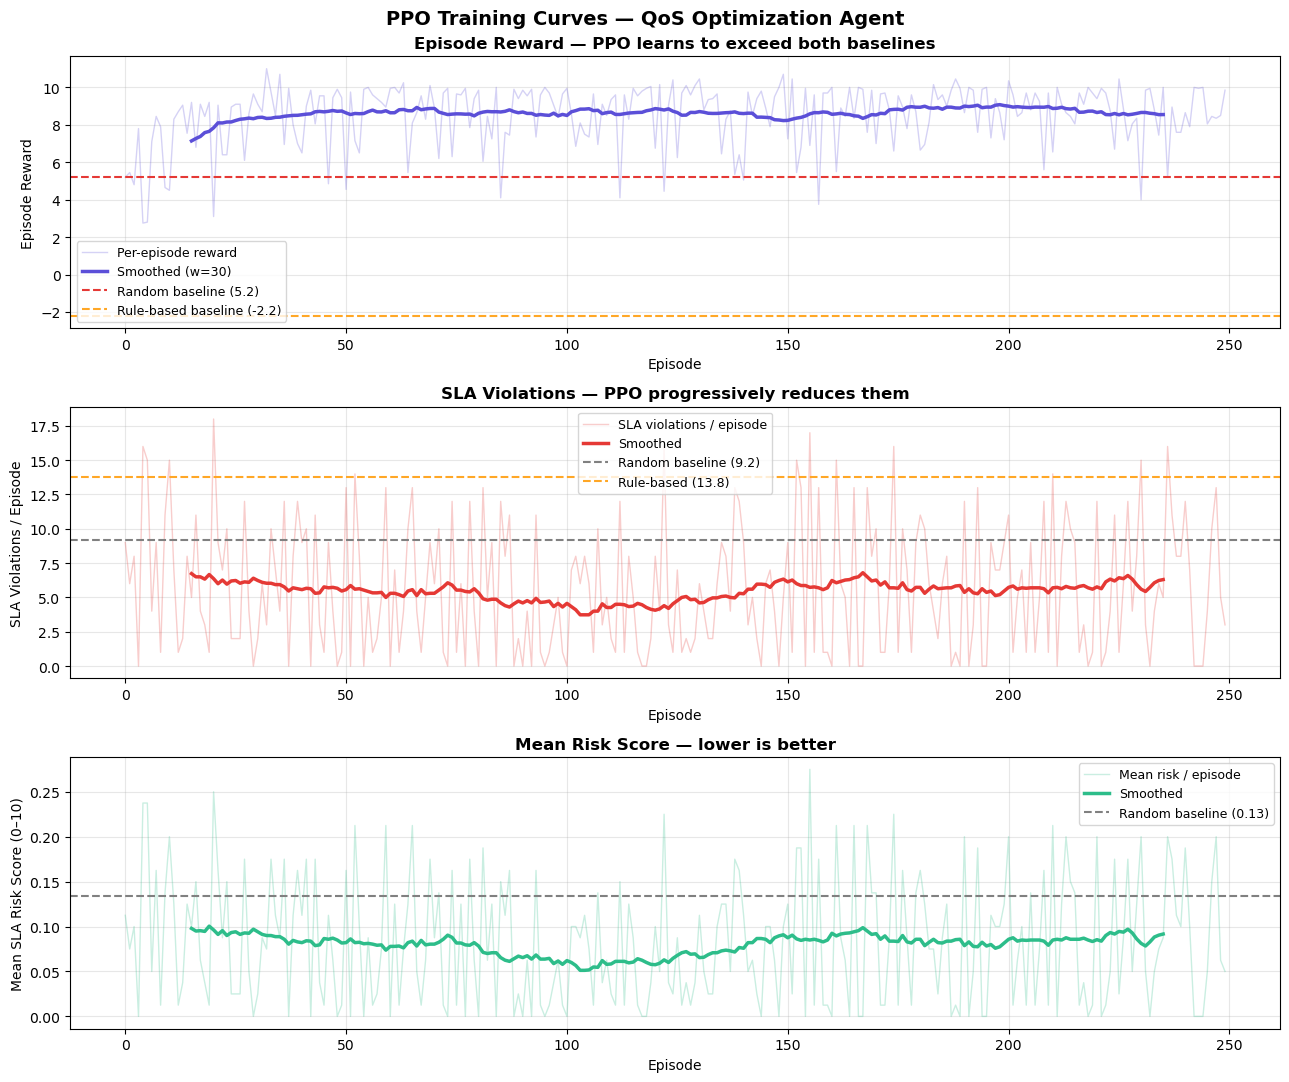

Saved: outputs/training_curves.png


In [8]:
# ── Training curves from MetricsCallback ─────────────────────────────────
ep_r   = np.array(metrics_cb.ep_rewards)
ep_v   = np.array(metrics_cb.ep_violations)
ep_rsk = np.array(metrics_cb.ep_risks)

def smooth(x, w=30):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=False)
fig.suptitle('PPO Training Curves — QoS Optimization Agent', fontsize=14, fontweight='bold')

# ── Reward ─────────────────────────────────────────────────────────────────
ax = axes[0]
eps = np.arange(len(ep_r))
ax.plot(eps, ep_r, alpha=0.25, color='#5B4FD8', lw=1, label='Per-episode reward')
s = smooth(ep_r)
ax.plot(np.arange(len(s)) + 15, s, color='#5B4FD8', lw=2.5, label='Smoothed (w=30)')
# baselines
ax.axhline(np.mean(rand_rewards),  color='#E53935', ls='--', lw=1.5,
           label=f'Random baseline ({np.mean(rand_rewards):.1f})')
ax.axhline(np.mean(rule_rewards),  color='#FFA726', ls='--', lw=1.5,
           label=f'Rule-based baseline ({np.mean(rule_rewards):.1f})')
ax.set_ylabel('Episode Reward'); ax.set_xlabel('Episode')
ax.set_title('Episode Reward — PPO learns to exceed both baselines', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Violations ────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(eps, ep_v, alpha=0.25, color='#E53935', lw=1, label='SLA violations / episode')
sv = smooth(ep_v)
ax.plot(np.arange(len(sv)) + 15, sv, color='#E53935', lw=2.5, label='Smoothed')
ax.axhline(np.mean(rand_violations), color='gray',    ls='--', lw=1.5,
           label=f'Random baseline ({np.mean(rand_violations):.1f})')
ax.axhline(np.mean(rule_violations), color='#FFA726', ls='--', lw=1.5,
           label=f'Rule-based ({np.mean(rule_violations):.1f})')
ax.set_ylabel('SLA Violations / Episode'); ax.set_xlabel('Episode')
ax.set_title('SLA Violations — PPO progressively reduces them', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Mean Risk Score ────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(eps, ep_rsk, alpha=0.25, color='#2DBD8A', lw=1, label='Mean risk / episode')
sr = smooth(ep_rsk)
ax.plot(np.arange(len(sr)) + 15, sr, color='#2DBD8A', lw=2.5, label='Smoothed')
ax.axhline(np.mean(rand_risks), color='gray', ls='--', lw=1.5,
           label=f'Random baseline ({np.mean(rand_risks):.2f})')
ax.set_ylabel('Mean SLA Risk Score (0–10)'); ax.set_xlabel('Episode')
ax.set_title('Mean Risk Score — lower is better', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/training_curves.png')


---
## 6. Policy Evaluation — PPO vs Baselines

In [9]:
# ── Load best checkpoint for eval ────────────────────────────────────────
best_model = PPO.load('checkpoints/best_model', env=eval_env)
print('Loaded best checkpoint ✓')

# ── Evaluate 20 episodes ──────────────────────────────────────────────────
def run_policy(policy_fn, n_ep=20, ep_len=200):
    env = QoSNetworkEnv(ns3_data_path=DATASET_PATH, episode_len=ep_len)
    rewards, violations, risks, action_counts = [], [], [], np.zeros(4)
    for _ in range(n_ep):
        obs, _ = env.reset()
        ep_r, ep_v, ep_rsk = 0.0, 0, []
        for _ in range(ep_len):
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_r  += reward
            ep_v  += info['sla_violation']
            ep_rsk.append(info['risk_score'])
            action_counts[action] += 1
            if terminated or truncated: break
        rewards.append(ep_r)
        violations.append(ep_v)
        risks.append(np.mean(ep_rsk))
    return {
        'reward_mean': np.mean(rewards), 'reward_std': np.std(rewards),
        'violations_mean': np.mean(violations),
        'violation_rate':  np.mean(violations) / ep_len * 100,
        'risk_mean':       np.mean(risks),
        'action_dist':     action_counts / action_counts.sum(),
    }

print('Evaluating all agents (20 episodes each)...')
results = {
    'Random':     run_policy(lambda obs: env_raw.action_space.sample()),
    'Rule-Based': run_policy(rule_based_action),
    'PPO (best)': run_policy(lambda obs: int(best_model.predict(obs, deterministic=True)[0])),
}

print()
print(f'{"Agent":<15} {"Reward":>10} {"±":>6} {"Violations":>12} {"Viol%":>7} {"Risk":>7}')
print('-' * 57)
for name, r in results.items():
    print(f'{name:<15} {r["reward_mean"]:>10.3f} {r["reward_std"]:>6.2f} '
          f'{r["violations_mean"]:>12.1f} {r["violation_rate"]:>6.1f}% {r["risk_mean"]:>7.3f}')


Loaded best checkpoint ✓
Evaluating all agents (20 episodes each)...
[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv



Agent               Reward      ±   Violations   Viol%    Risk
---------------------------------------------------------
Random               5.367   1.63          8.2    4.1%   0.111
Rule-Based          -1.113   1.70         11.2    5.6%   0.164
PPO (best)           9.040   1.35          4.0    2.0%   0.056


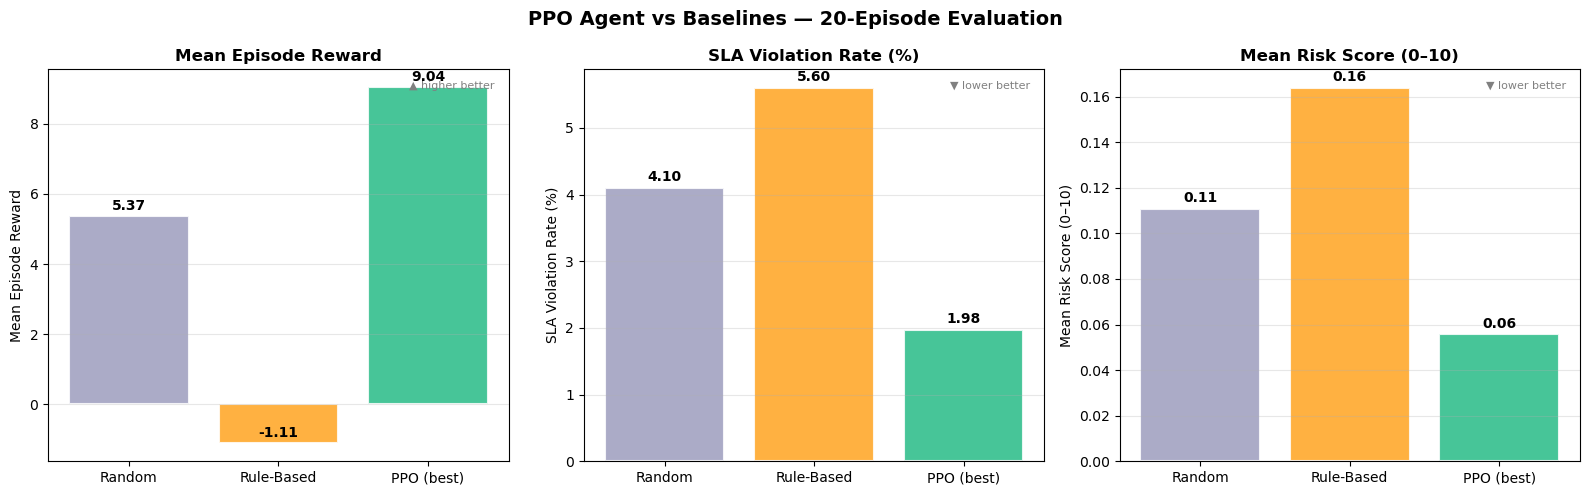

Saved: outputs/agent_comparison.png


In [10]:
# ── Comparison bar charts ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PPO Agent vs Baselines — 20-Episode Evaluation',
             fontsize=14, fontweight='bold')

agents  = list(results.keys())
colors  = ['#A0A0C0', '#FFA726', '#2DBD8A']
metrics = [
    ('reward_mean',     'Mean Episode Reward',    True ),
    ('violation_rate',  'SLA Violation Rate (%)', False),
    ('risk_mean',       'Mean Risk Score (0–10)', False),
]

for ax, (key, title, higher_better) in zip(axes, metrics):
    vals  = [results[a][key] for a in agents]
    bars  = ax.bar(agents, vals, color=colors, alpha=0.88, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)
    arrow = '▲ higher better' if higher_better else '▼ lower better'
    ax.text(0.97, 0.97, arrow, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('outputs/agent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/agent_comparison.png')


---
## 7. Action Distribution & Per-Load-Level Analysis

In [11]:
# ── Collect detailed episode data for PPO ─────────────────────────────────
print('Collecting detailed trajectory data (PPO best model, 50 episodes)...')
env_det = QoSNetworkEnv(ns3_data_path=DATASET_PATH, episode_len=200)
traj = []

for ep in range(50):
    obs, _ = env_det.reset()
    for step in range(200):
        action, _ = best_model.predict(obs, deterministic=True)
        action = int(action)
        obs_next, reward, terminated, truncated, info = env_det.step(action)
        traj.append({
            'episode': ep, 'step': step, 'action': action,
            'action_name': QoSNetworkEnv.ACTION_NAMES[action],
            'reward': reward,
            'sla_violation': info['sla_violation'],
            'risk_score':    info['risk_score'],
            'load_level':    info['load_level'],
            'sinr_dl_db':    info['sinr_dl_db'],
            'delay_ms':      info['delay_ms'],
            'throughput_mbps': info['throughput_mbps'],
        })
        obs = obs_next
        if terminated or truncated: break

df_traj = pd.DataFrame(traj)
print(f'Trajectory rows: {len(df_traj):,}')
print(df_traj['action_name'].value_counts().to_string())


[QoSNetworkEnv] Loaded 18,580 NS-3 rows from lena_dataset_cleaned.csv


Trajectory rows: 10,000
action_name
throttle      6559
prioritize    2530
reroute        911


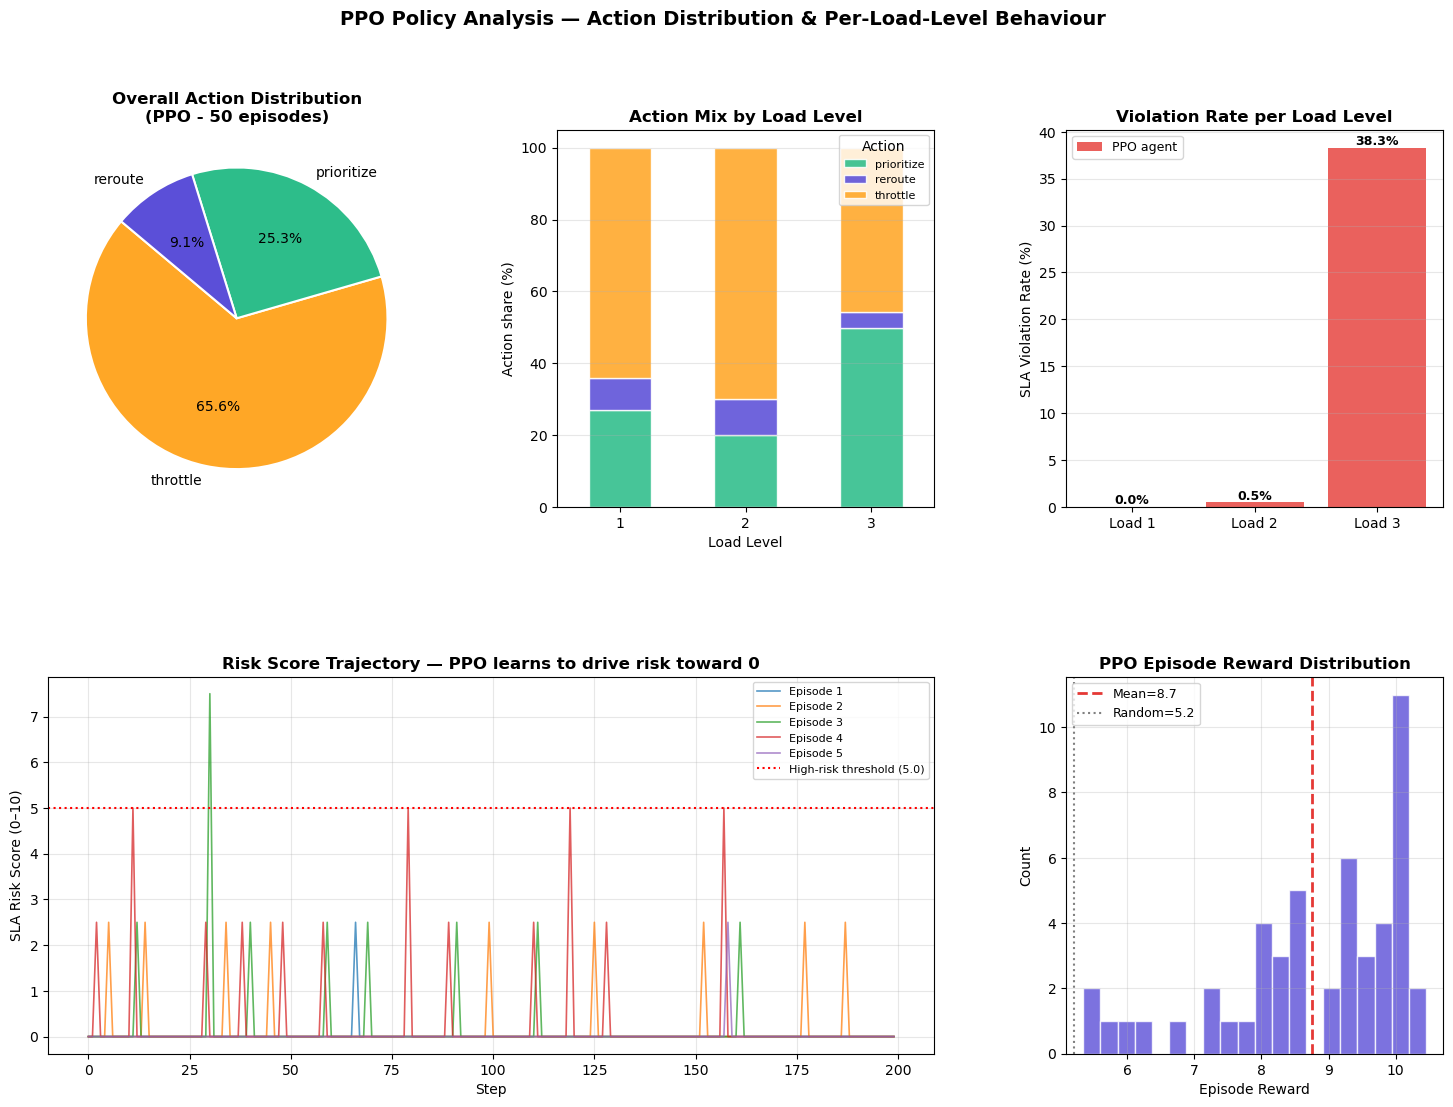

Saved: outputs/policy_analysis.png


In [12]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('PPO Policy Analysis — Action Distribution & Per-Load-Level Behaviour',
             fontsize=14, fontweight='bold')

# Panel 1: Overall action distribution pie
ax1 = fig.add_subplot(gs[0, 0])
act_counts = df_traj['action_name'].value_counts()
act_colors = {'reroute':'#5B4FD8','throttle':'#FFA726',
              'prioritize':'#2DBD8A','no_action':'#A0A0C0'}
wedge_colors = [act_colors.get(a, '#999') for a in act_counts.index]
ax1.pie(act_counts.values, labels=act_counts.index, autopct='%1.1f%%',
        colors=wedge_colors, startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax1.set_title('Overall Action Distribution\n(PPO - 50 episodes)', fontweight='bold')

# Panel 2: Action distribution per load level
ax2 = fig.add_subplot(gs[0, 1])
act_load = df_traj.groupby(['load_level','action_name']).size().unstack(fill_value=0)
act_load_pct = act_load.div(act_load.sum(axis=1), axis=0) * 100
act_load_pct.plot(kind='bar', ax=ax2, stacked=True,
                  color=[act_colors.get(c,'#999') for c in act_load_pct.columns],
                  alpha=0.88, edgecolor='white')
ax2.set_title('Action Mix by Load Level', fontweight='bold')
ax2.set_xlabel('Load Level'); ax2.set_ylabel('Action share (%)')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Action', fontsize=8, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Violation rate per load level
ax3 = fig.add_subplot(gs[0, 2])
viol_load = df_traj.groupby('load_level')['sla_violation'].mean() * 100
rand_viol_load = df_traj.groupby('load_level')['load_level'].count() * 0  # placeholder
x = np.arange(len(viol_load))
ax3.bar(x, viol_load.values, color='#E53935', alpha=0.8, label='PPO agent')
ax3.set_xticks(x); ax3.set_xticklabels([f'Load {l}' for l in viol_load.index])
ax3.set_ylabel('SLA Violation Rate (%)'); ax3.set_title('Violation Rate per Load Level', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(viol_load.values):
    ax3.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 4: Risk score over time (first 5 episodes)
ax4 = fig.add_subplot(gs[1, :2])
for ep in range(min(5, df_traj['episode'].nunique())):
    ep_data = df_traj[df_traj['episode'] == ep]
    ax4.plot(ep_data['step'], ep_data['risk_score'], lw=1.2, alpha=0.75,
             label=f'Episode {ep+1}')
ax4.set_xlabel('Step'); ax4.set_ylabel('SLA Risk Score (0–10)')
ax4.set_title('Risk Score Trajectory — PPO learns to drive risk toward 0', fontweight='bold')
ax4.axhline(5.0, color='red', ls=':', lw=1.5, label='High-risk threshold (5.0)')
ax4.legend(fontsize=8, loc='upper right'); ax4.grid(alpha=0.3)

# Panel 5: Reward distribution
ax5 = fig.add_subplot(gs[1, 2])
ep_rewards_det = df_traj.groupby('episode')['reward'].sum()
ax5.hist(ep_rewards_det, bins=20, color='#5B4FD8', alpha=0.8, edgecolor='white')
ax5.axvline(ep_rewards_det.mean(), color='#E53935', ls='--', lw=2,
            label=f'Mean={ep_rewards_det.mean():.1f}')
ax5.axvline(np.mean(rand_rewards), color='gray', ls=':', lw=1.5,
            label=f'Random={np.mean(rand_rewards):.1f}')
ax5.set_xlabel('Episode Reward'); ax5.set_ylabel('Count')
ax5.set_title('PPO Episode Reward Distribution', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

plt.savefig('outputs/policy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/policy_analysis.png')


---
## 8. SLA Violation Heatmap & KPI Trajectories

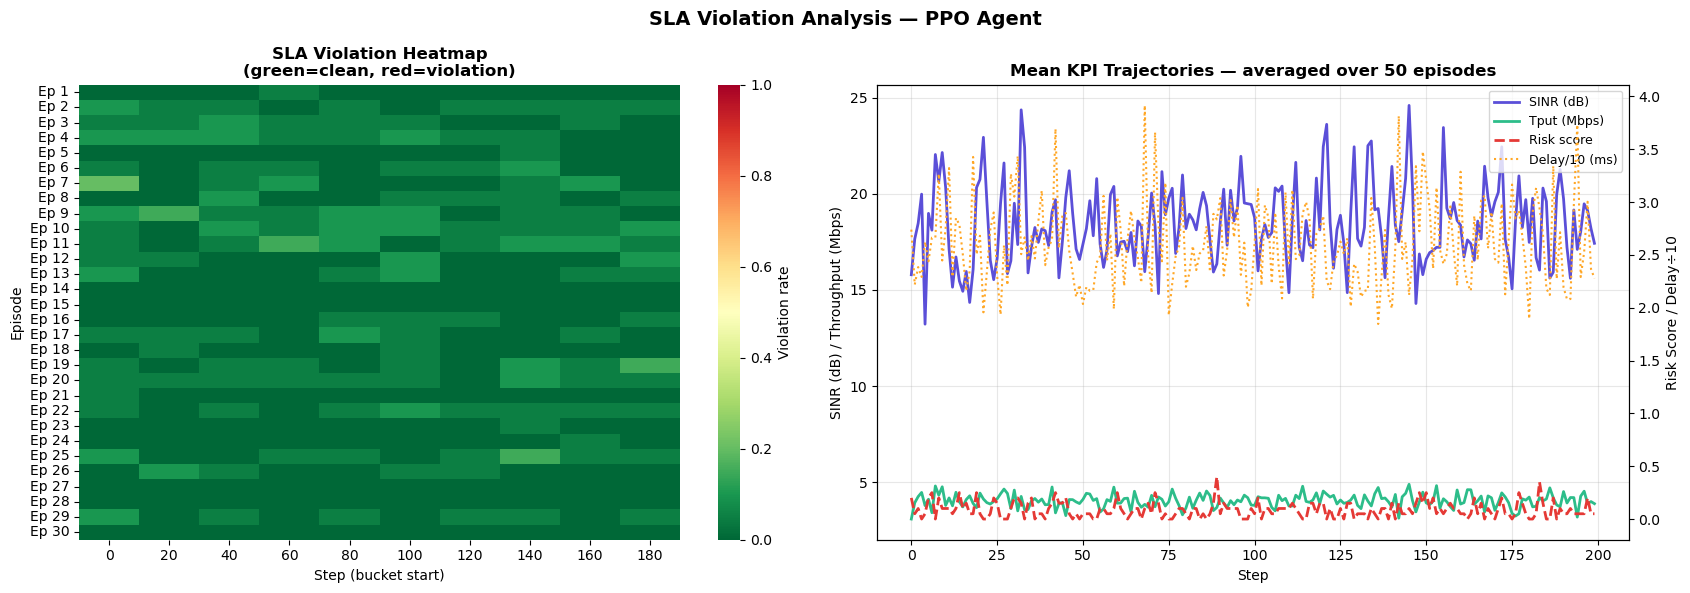

Saved: outputs/sla_heatmap.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('SLA Violation Analysis — PPO Agent', fontsize=14, fontweight='bold')

# ── Heatmap: violation by (episode × step bucket) ─────────────────────────
ax = axes[0]
N_EPISODES_HM = min(30, df_traj['episode'].nunique())
N_BUCKETS     = 10
bucket_size   = 200 // N_BUCKETS
hm_data = np.zeros((N_EPISODES_HM, N_BUCKETS))
for ep in range(N_EPISODES_HM):
    ep_d = df_traj[df_traj['episode'] == ep]
    for b in range(N_BUCKETS):
        s, e = b * bucket_size, (b+1) * bucket_size
        chunk = ep_d[(ep_d['step'] >= s) & (ep_d['step'] < e)]
        hm_data[ep, b] = chunk['sla_violation'].mean() if len(chunk) > 0 else 0.0

sns.heatmap(hm_data, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
            cbar_kws={'label': 'Violation rate'},
            xticklabels=[f'{i*bucket_size}' for i in range(N_BUCKETS)],
            yticklabels=[f'Ep {i+1}' for i in range(N_EPISODES_HM)])
ax.set_xlabel('Step (bucket start)'); ax.set_ylabel('Episode')
ax.set_title('SLA Violation Heatmap\n(green=clean, red=violation)', fontweight='bold')

# ── KPI trajectories (mean across episodes) ───────────────────────────────
ax2 = axes[1]
kpi_mean = df_traj.groupby('step')[['sinr_dl_db','delay_ms','throughput_mbps','risk_score']].mean()

ax2_r = ax2.twinx()
ax2.plot(kpi_mean.index, kpi_mean['sinr_dl_db'],    color='#5B4FD8', lw=2, label='SINR (dB)')
ax2.plot(kpi_mean.index, kpi_mean['throughput_mbps'],color='#2DBD8A', lw=2, label='Tput (Mbps)')
ax2_r.plot(kpi_mean.index, kpi_mean['risk_score'],   color='#E53935', lw=2, ls='--', label='Risk score')
ax2_r.plot(kpi_mean.index, kpi_mean['delay_ms']/10,  color='#FFA726', lw=1.5, ls=':', label='Delay/10 (ms)')

ax2.set_xlabel('Step'); ax2.set_ylabel('SINR (dB) / Throughput (Mbps)')
ax2_r.set_ylabel('Risk Score / Delay÷10')
ax2.set_title('Mean KPI Trajectories — averaged over 50 episodes', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/sla_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/sla_heatmap.png')


---
## 9. Final Benchmark Table

In [14]:
import pandas as pd

summary = pd.DataFrame([
    {'Agent': 'Random',     **{k: results['Random'][k]     for k in ['reward_mean','violation_rate','risk_mean']}},
    {'Agent': 'Rule-Based', **{k: results['Rule-Based'][k] for k in ['reward_mean','violation_rate','risk_mean']}},
    {'Agent': 'PPO (best)', **{k: results['PPO (best)'][k] for k in ['reward_mean','violation_rate','risk_mean']}},
]).set_index('Agent').rename(columns={
    'reward_mean':    'Mean Reward',
    'violation_rate': 'Violation Rate (%)',
    'risk_mean':      'Mean Risk Score',
})

print('='*60)
print('  FINAL BENCHMARK — 20-Episode Evaluation')
print('='*60)
print(summary.to_string())
print('='*60)

# Improvement over random
ppo_r  = results['PPO (best)']['reward_mean']
rand_r = results['Random']['reward_mean']
rule_r = results['Rule-Based']['reward_mean']
ppo_v  = results['PPO (best)']['violation_rate']
rand_v = results['Random']['violation_rate']

print(f'\nPPO vs Random:')
print(f'  Reward improvement : {ppo_r - rand_r:+.2f} ({(ppo_r-rand_r)/abs(rand_r)*100:+.1f}%)')
print(f'  Violation reduction: {rand_v - ppo_v:+.1f} pp')
print(f'\nPPO vs Rule-Based:')
print(f'  Reward improvement : {ppo_r - rule_r:+.2f}')


  FINAL BENCHMARK — 20-Episode Evaluation
            Mean Reward  Violation Rate (%)  Mean Risk Score
Agent                                                       
Random           5.3675               4.100         0.110625
Rule-Based      -1.1125               5.600         0.163750
PPO (best)       9.0400               1.975         0.055625

PPO vs Random:
  Reward improvement : +3.67 (+68.4%)
  Violation reduction: +2.1 pp

PPO vs Rule-Based:
  Reward improvement : +10.15


---
## 10. Export — Model + Inference Script

In [15]:
# ── Save final model ──────────────────────────────────────────────────────
model.save('ppo_qos_agent_v1')
best_model.save('ppo_qos_agent_best')
print('Saved: ppo_qos_agent_v1.zip')
print('Saved: ppo_qos_agent_best.zip')

# ── Export inference script ───────────────────────────────────────────────
inference_script = '''#!/usr/bin/env python3
"""
inference.py — Load trained PPO agent and run on QoSNetworkEnv.
Usage: python inference.py [--episodes 10] [--dataset lena_dataset_cleaned.csv]
"""
import os, sys, argparse
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
from stable_baselines3 import PPO
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from QoSNetworkEnv import QoSNetworkEnv

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--episodes', type=int, default=10)
    parser.add_argument('--dataset',  type=str, default='lena_dataset_cleaned.csv')
    parser.add_argument('--model',    type=str, default='ppo_qos_agent_best')
    args = parser.parse_args()

    env   = QoSNetworkEnv(ns3_data_path=args.dataset, episode_len=200)
    agent = PPO.load(args.model, env=env)
    print(f"Loaded model: {args.model}")
    print(f"Running {args.episodes} episodes...")

    all_rewards, all_violations = [], []
    for ep in range(args.episodes):
        obs, _ = env.reset()
        ep_r, ep_v = 0.0, 0
        done = False
        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            ep_r += reward
            ep_v += info["sla_violation"]
            done = terminated or truncated
        all_rewards.append(ep_r)
        all_violations.append(ep_v)
        print(f"  Ep {ep+1:2d}: reward={ep_r:6.2f}  violations={ep_v}")

    print(f"\nMean reward    : {np.mean(all_rewards):.3f}")
    print(f"Mean violations: {np.mean(all_violations):.1f}")

if __name__ == "__main__":
    main()
'''

with open('inference.py', 'w') as f:
    f.write(inference_script)
print('Saved: inference.py')

# ── Export config ─────────────────────────────────────────────────────────
config = {
    'module':          'M1 — RL Agent (DSO3.1)',
    'algorithm':       'PPO',
    'library':         'stable-baselines3',
    'total_timesteps': 200_000,
    'n_envs':          4,
    'episode_len':     200,
    'policy':          'MlpPolicy',
    'net_arch':        [128, 128],
    'learning_rate':   3e-4,
    'gamma':           0.99,
    'ent_coef':        0.01,
    'environment':     'QoSNetworkEnv v3',
    'dataset':         'lena_dataset_cleaned.csv',
    'model_files': {
        'best':  'ppo_qos_agent_best.zip',
        'final': 'ppo_qos_agent_v1.zip',
    },
    'benchmark': {a: {k: round(float(v),4) for k,v in r.items() if isinstance(v,(int,float))}
                  for a, r in results.items()},
    'handoff_to': 'Module D — Dashboard / Self-Healing Controller',
}
with open('rl_agent_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved: rl_agent_config.json')

print()
print('='*55)
print('  M1 RL AGENT — EXPORT SUMMARY')
print('='*55)
for fn in sorted(os.listdir('.')):
    if fn.endswith(('.zip','.json','.py','.png')) and not fn.startswith('build'):
        sz = os.path.getsize(fn)/1024
        print(f'  {fn:<40} {sz:6.1f} KB')
for fn in sorted(os.listdir('outputs')):
    sz = os.path.getsize(f'outputs/{fn}')/1024
    print(f'  outputs/{fn:<32} {sz:6.1f} KB')
print('='*55)


Saved: ppo_qos_agent_v1.zip
Saved: ppo_qos_agent_best.zip
Saved: inference.py
Saved: rl_agent_config.json

  M1 RL AGENT — EXPORT SUMMARY
  QoSNetworkEnv.py                            8.0 KB
  inference.py                                1.6 KB
  ns3_environment_config.json                 1.5 KB
  ppo_qos_agent_best.zip                    455.6 KB
  ppo_qos_agent_v1.zip                      456.0 KB
  rl_agent_config.json                        1.1 KB
  outputs/agent_comparison.png               92.4 KB
  outputs/policy_analysis.png               252.2 KB
  outputs/sla_heatmap.png                   338.9 KB
  outputs/training_curves.png               515.7 KB
